# SongNet: Real-time Music Genre Classification - Colab runner

UE24CS352A Machine Learning Mini-Project

This notebook records the full pipeline we ran on Google Colab, with the real outputs from our runs:
data download and split, mel-spectrogram extraction, classical baselines, C-RNN training, and test evaluation.
The steps ran in two Colab sessions (CPU steps, then a GPU session for training); intermediate files were saved
to Google Drive under `MyDrive/songnet`. The same code is available as scripts in `src/`.

## 1. Download FMA (small), create the stratified 70/20/10 split

In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

%cd /content

# Download only what is missing (safe to re-run any time)
if not os.path.exists('fma_metadata/tracks.csv'):
    !wget -q https://os.unil.cloud.switch.ch/fma/fma_metadata.zip
    !unzip -q -o fma_metadata.zip && rm -f fma_metadata.zip
if not os.path.exists('fma_small'):
    !wget -q https://os.unil.cloud.switch.ch/fma/fma_small.zip
    !unzip -q -o fma_small.zip && rm -f fma_small.zip

# Labels for the fma_small subset
tracks = pd.read_csv('fma_metadata/tracks.csv', index_col=0, header=[0, 1])
small = tracks[tracks['set', 'subset'] == 'small']
df = pd.DataFrame({'genre': small['track', 'genre_top']})
df.index.name = 'track_id'
print('Total tracks:', len(df))
print(df['genre'].value_counts())

# Check that every audio file exists
def audio_path(t):
    s = f'{t:06d}'
    return f'fma_small/{s[:3]}/{s}.mp3'
print('Missing files:', sum(not os.path.exists(audio_path(t)) for t in df.index))

# Stratified 70/20/10 split
train, temp = train_test_split(df, test_size=0.30, stratify=df['genre'], random_state=42)
val, test = train_test_split(temp, test_size=1/3, stratify=temp['genre'], random_state=42)
df['split'] = 'train'
df.loc[val.index, 'split'] = 'val'
df.loc[test.index, 'split'] = 'test'
print(df['split'].value_counts())

# Save and download to your computer
df.to_csv('splits.csv')
from google.colab import files
files.download('splits.csv')

/content
Total tracks: 8000
genre
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64
Missing files: 0
split
train    5600
val      1600
test      800
Name: count, dtype: int64


## 2. Mount Google Drive and save the split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, shutil
os.makedirs('/content/drive/MyDrive/songnet/features', exist_ok=True)
shutil.copy('/content/splits.csv', '/content/drive/MyDrive/songnet/')

'/content/drive/MyDrive/songnet/splits.csv'

## 3. Mel-spectrogram function (22.05 kHz, 128 mel bins, 1290 frames per 30 s clip)

In [4]:
import numpy as np, pandas as pd, librosa, os
from joblib import Parallel, delayed

SR, N_FFT, HOP, N_MELS, N_FRAMES = 22050, 2048, 512, 128, 1290

def audio_path(t):
    s = f'{t:06d}'
    return f'/content/fma_small/{s[:3]}/{s}.mp3'

def mel(path):
    try:
        y, _ = librosa.load(path, sr=SR, mono=True, duration=30)
        S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
        S = librosa.power_to_db(S, ref=np.max, top_db=80)
        S = ((S + 40) / 40).T.astype(np.float16)      # shape (time, mel bins)
        if S.shape[0] < N_FRAMES:                      # pad short clips with silence
            S = np.pad(S, ((0, N_FRAMES - S.shape[0]), (0, 0)), constant_values=-1)
        return S[:N_FRAMES], True
    except Exception:
        return np.full((N_FRAMES, N_MELS), -1, dtype=np.float16), False

df = pd.read_csv('/content/splits.csv', index_col=0)
print(df['split'].value_counts())

split
train    5600
val      1600
test      800
Name: count, dtype: int64


## 4. Extract and cache mel-spectrograms to Drive in chunks (resumable)
A few corrupted mp3s are skipped, leaving 5,599 / 1,599 / 799 clips.

In [5]:
import os, numpy as np
from joblib import Parallel, delayed

OUT = '/content/drive/MyDrive/songnet/features'
os.makedirs(OUT, exist_ok=True)

genres = sorted(df['genre'].unique())
label = {g: i for i, g in enumerate(genres)}
CHUNK = 500

for split in ['train', 'val', 'test']:
    part = df[df['split'] == split]
    ids = part.index.tolist()
    for i in range(0, len(ids), CHUNK):
        f = f'{OUT}/{split}_{i//CHUNK:03d}.npz'
        if os.path.exists(f):
            continue                      # already saved, skip it
        chunk = ids[i:i+CHUNK]
        res = Parallel(n_jobs=-1)(delayed(mel)(audio_path(t)) for t in chunk)
        ok = np.array([r[1] for r in res])
        X = np.stack([r[0] for r in res])[ok]
        y = part.loc[chunk, 'genre'].map(label).values[ok]
        np.savez(f, X=X, y=y)
        print(f, X.shape, flush=True)

print('DONE', genres)

/content/drive/MyDrive/songnet/features/train_000.npz (500, 1290, 128)
/content/drive/MyDrive/songnet/features/train_001.npz (500, 1290, 128)
/content/drive/MyDrive/songnet/features/train_002.npz (500, 1290, 128)
/content/drive/MyDrive/songnet/features/train_003.npz (500, 1290, 128)
/content/drive/MyDrive/songnet/features/train_004.npz (500, 1290, 128)
/content/drive/MyDrive/songnet/features/train_005.npz (500, 1290, 128)
/content/drive/MyDrive/songnet/features/train_006.npz (499, 1290, 128)
/content/drive/MyDrive/songnet/features/train_007.npz (500, 1290, 128)
/content/drive/MyDrive/songnet/features/train_008.npz (500, 1290, 128)
/content/drive/MyDrive/songnet/features/train_009.npz (500, 1290, 128)
/content/drive/MyDrive/songnet/features/train_010.npz (500, 1290, 128)
/content/drive/MyDrive/songnet/features/train_011.npz (100, 1290, 128)
/content/drive/MyDrive/songnet/features/val_000.npz (500, 1290, 128)
/content/drive/MyDrive/songnet/features/val_001.npz (500, 1290, 128)
/content/d

## 5. Baselines: k-NN, Logistic Regression, MLP, Linear SVM on the precomputed FMA features (518 features)

In [6]:
import pandas as pd, numpy as np, time, warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

splits = pd.read_csv('/content/splits.csv', index_col=0)
feats = pd.read_csv('/content/fma_metadata/features.csv', index_col=0, header=[0, 1, 2])
feats = feats.loc[splits.index]
print('Feature matrix:', feats.shape)

Xtr, Xva, Xte = [feats[splits['split'] == s].values for s in ['train', 'val', 'test']]
ytr, yva, yte = [splits.loc[splits['split'] == s, 'genre'].values for s in ['train', 'val', 'test']]

sc = StandardScaler().fit(np.nan_to_num(Xtr))
Xtr, Xva, Xte = [sc.transform(np.nan_to_num(a)) for a in (Xtr, Xva, Xte)]

models = {
    'k-NN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'MLP': MLPClassifier(hidden_layer_sizes=(256,), max_iter=300, random_state=42),
    'Linear SVM': LinearSVC(max_iter=5000),
}
rows = []
for name, m in models.items():
    t = time.time()
    m.fit(Xtr, ytr)
    rows.append((name, accuracy_score(yva, m.predict(Xva)), accuracy_score(yte, m.predict(Xte))))
    print(f'{name:20s} val={rows[-1][1]:.3f}  test={rows[-1][2]:.3f}  ({time.time() - t:.0f}s)')

results = pd.DataFrame(rows, columns=['Model', 'Val acc', 'Test acc']).round(4)
print(results.to_string(index=False))
results.to_csv('/content/baseline_results.csv', index=False)

Feature matrix: (8000, 518)
k-NN                 val=0.469  test=0.445  (0s)
Logistic Regression  val=0.541  test=0.545  (11s)
MLP                  val=0.590  test=0.580  (24s)
Linear SVM           val=0.546  test=0.535  (479s)
              Model  Val acc  Test acc
               k-NN   0.4688     0.445
Logistic Regression   0.5412     0.545
                MLP   0.5900     0.580
         Linear SVM   0.5462     0.535


## 6. Load cached features on a GPU runtime

In [7]:
from google.colab import drive
drive.mount('/content/drive')
import os, glob, numpy as np, torch, torch.nn as nn, torch.nn.functional as F

dev = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using:', dev)
D = '/content/drive/MyDrive/songnet'

def load(split):
    X, y = [], []
    for f in sorted(glob.glob(f'{D}/features/{split}_*.npz')):
        z = np.load(f); X.append(z['X']); y.append(z['y'])
    return (torch.from_numpy(np.concatenate(X)).to(dev),
            torch.from_numpy(np.concatenate(y)).long().to(dev))

Xtr, ytr = load('train'); Xva, yva = load('val'); Xte, yte = load('test')
print(Xtr.shape, Xva.shape, Xte.shape)

Mounted at /content/drive
Using: cuda
torch.Size([5599, 1290, 128]) torch.Size([1599, 1290, 128]) torch.Size([799, 1290, 128])


## 7. C-RNN model: 1-D convolutions along time, GRU, a genre prediction at every timestep

In [8]:
class SongNet(nn.Module):
    def __init__(s, n_mels=128, n_classes=8):
        super().__init__()
        s.conv = nn.Sequential(
            nn.Conv1d(n_mels, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Dropout(0.3))
        s.gru = nn.GRU(128, 128, batch_first=True)
        s.fc = nn.Linear(128, n_classes)
    def forward(s, x):                       # x: (batch, time, mel)
        h = s.conv(x.transpose(1, 2)).transpose(1, 2)
        h, _ = s.gru(h)
        return s.fc(h)                       # a genre prediction at every timestep

## 8. Train (checkpoint saved to Drive every epoch; rerunning resumes)

In [9]:
model = SongNet().to(dev)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
CK, BEST = f'{D}/ckpt.pt', f'{D}/best.pt'
EPOCHS, BS, CROP = 30, 64, 256
start, best = 0, 0.0
if os.path.exists(CK):
    c = torch.load(CK)
    model.load_state_dict(c['model']); opt.load_state_dict(c['opt'])
    start, best = c['epoch'] + 1, c['best']
    print('Resuming from epoch', start)

@torch.no_grad()
def evaluate(X, y):
    model.eval(); correct = 0
    for i in range(0, len(X), 64):
        p = F.softmax(model(X[i:i+64].float()), -1).mean(1)   # average over time
        correct += (p.argmax(1) == y[i:i+64]).sum().item()
    return correct / len(X)

for ep in range(start, EPOCHS):
    model.train(); total = 0
    perm = torch.randperm(len(Xtr), device=dev)
    for i in range(0, len(perm) - BS + 1, BS):
        idx = perm[i:i+BS]
        s = np.random.randint(0, Xtr.shape[1] - CROP)
        out = model(Xtr[idx, s:s+CROP].float())
        loss = F.cross_entropy(out.reshape(-1, 8), ytr[idx].repeat_interleave(out.shape[1]))
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    va = evaluate(Xva, yva)
    if va > best:
        best = va; torch.save(model.state_dict(), BEST)
    torch.save({'model': model.state_dict(), 'opt': opt.state_dict(), 'epoch': ep, 'best': best}, CK)
    print(f'epoch {ep+1}/{EPOCHS}  loss {total/(len(perm)//BS):.3f}  val acc {va:.3f}  best {best:.3f}', flush=True)

epoch 1/30  loss 1.774  val acc 0.391  best 0.391
epoch 2/30  loss 1.674  val acc 0.414  best 0.414
epoch 3/30  loss 1.604  val acc 0.445  best 0.445
epoch 4/30  loss 1.572  val acc 0.458  best 0.458
epoch 5/30  loss 1.535  val acc 0.486  best 0.486
epoch 6/30  loss 1.487  val acc 0.511  best 0.511
epoch 7/30  loss 1.474  val acc 0.516  best 0.516
epoch 8/30  loss 1.450  val acc 0.516  best 0.516
epoch 9/30  loss 1.411  val acc 0.526  best 0.526
epoch 10/30  loss 1.387  val acc 0.518  best 0.526
epoch 11/30  loss 1.372  val acc 0.506  best 0.526
epoch 12/30  loss 1.355  val acc 0.527  best 0.527
epoch 13/30  loss 1.335  val acc 0.535  best 0.535
epoch 14/30  loss 1.324  val acc 0.538  best 0.538
epoch 15/30  loss 1.322  val acc 0.556  best 0.556
epoch 16/30  loss 1.289  val acc 0.552  best 0.556
epoch 17/30  loss 1.279  val acc 0.553  best 0.556
epoch 18/30  loss 1.264  val acc 0.542  best 0.556
epoch 19/30  loss 1.248  val acc 0.554  best 0.556
epoch 20/30  loss 1.230  val acc 0.561  

## 9. Test accuracy and confusion matrix (best checkpoint by validation accuracy)

Test accuracy: 0.6020025031289111


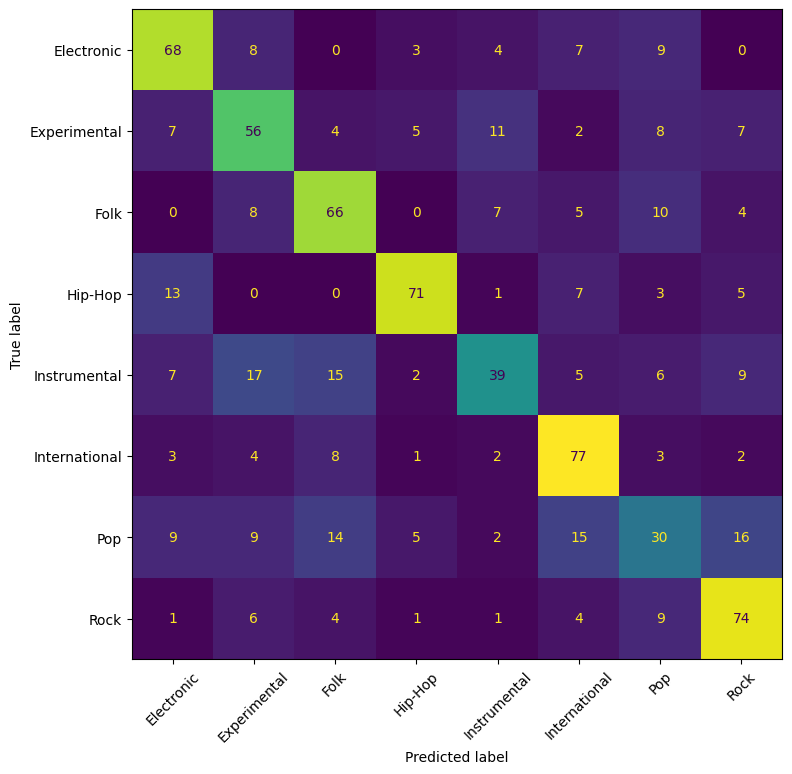

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

genres = ['Electronic','Experimental','Folk','Hip-Hop','Instrumental','International','Pop','Rock']
model.load_state_dict(torch.load(BEST)); model.eval()

preds = []
with torch.no_grad():
    for i in range(0, len(Xte), 64):
        p = F.softmax(model(Xte[i:i+64].float()), -1).mean(1)
        preds.append(p.argmax(1).cpu())
preds = torch.cat(preds).numpy(); true = yte.cpu().numpy()
print('Test accuracy:', (preds == true).mean())

cm = confusion_matrix(true, preds)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=genres).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.savefig(f'{D}/confusion_matrix.png', dpi=150)
plt.show()